In [14]:
import sys
sys.path.append('..')  

import numpy as np
import matplotlib.pyplot as plt
import importlib
from src.data_access import hf_client
import range_engine
from src import dsp_engine
importlib.reload(dsp_engine)

<module 'src.dsp_engine' from 'f:\\githup\\RADAR\\radar-dsp-core-main\\testing\\..\\src\\dsp_engine.py'>

In [2]:
from src.data_access import hf_client
import range_engine
from src import dsp_engine

print("All imports are working!")

All imports are working!


In [3]:
print("Number of frames:", hf_client.num_frames())

Number of frames: 19754


In [4]:
raw_frame = hf_client.get_frame(0)

print("Shape:", raw_frame.shape)
print("Data type:", raw_frame.dtype)

2019_04_09_bms1000/radar_raw_frame/00000(…): reconstructing file:   0%|          |  0.00B / 1.04MB            

2019_04_09_bms1000/radar_raw_frame/00000(…): downloading bytes:           |  0.00B            

Shape: (128, 255, 4, 2)
Data type: complex128


f:\githup\RADAR\radar-dsp-core-main\venv313\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\AL Motahida\.cache\huggingface\hub\datasets--hany34--raw-adc-data-77ghz-mmwave-radar-automotive-object-detection. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [5]:
raw_cube = raw_frame[:, :, :, 0].transpose(2, 1, 0)

print("Raw frame shape:", raw_frame.shape)
print("Raw cube shape:", raw_cube.shape)

Raw frame shape: (128, 255, 4, 2)
Raw cube shape: (4, 255, 128)


In [6]:


FC = 77e9
B = 0.67e9
TC = 60e-6

print("Carrier frequency:", FC / 1e9, "GHz")
print("Bandwidth:", B / 1e6, "MHz")
print("Chirp time:", TC * 1e6, "us")

Carrier frequency: 77.0 GHz
Bandwidth: 670.0 MHz
Chirp time: 60.0 us


In [8]:
range_fft, range_axis = range_engine.process_range_fft(
    raw_cube,
    Tc=TC,
    B=B,
    window_type="hann"
)

print("Range FFT shape:", range_fft.shape)
print("Range axis shape:", range_axis.shape)

Range FFT shape: (4, 255, 64)
Range axis shape: (64,)


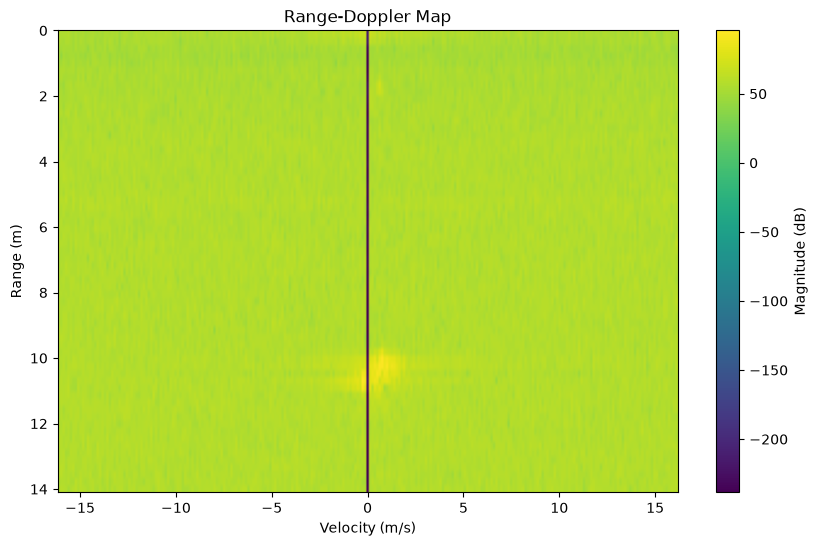

In [15]:
results = dsp_engine. process_dsp_and_plot(
    range_matrix=range_fft,
    range_axis=range_axis,
    chirp_repetition_time=TC,
    carrier_frequency=FC
)

(
    clean_matrix,
    doppler_spectrum,
    velocity,
    rdm,
    rdm_db,
    angle_spectrum,
    azimuth
) = results

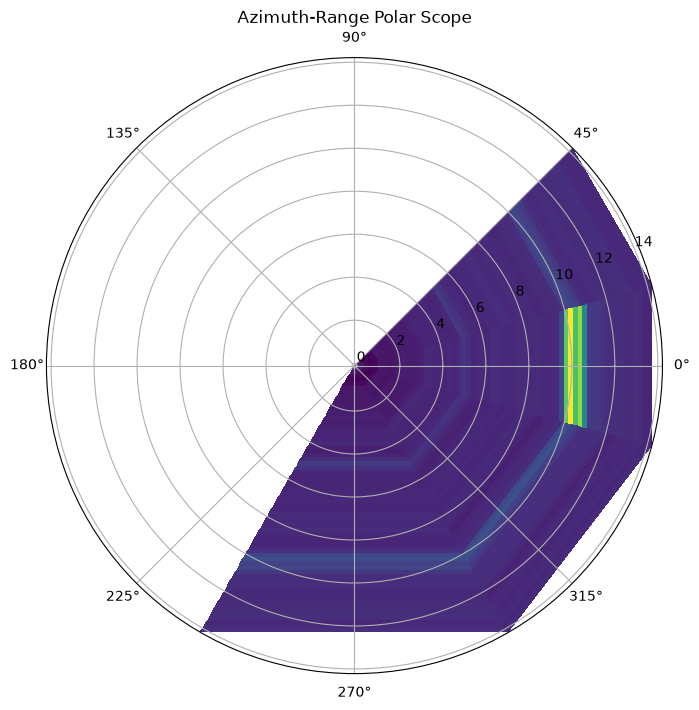

In [16]:
dsp_engine.plot_polar_scope(
    angle_spectrum,
    azimuth,
    range_axis
)